### Group Feed type and finding mean


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
df = pd.read_csv("../module2/chickwts.csv")
df.groupby("feed")["weight"].mean().sort_values()


feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

### Create Bar Chart For Food Type by Mean

Text(0, 0.5, 'Average Weight (g)')

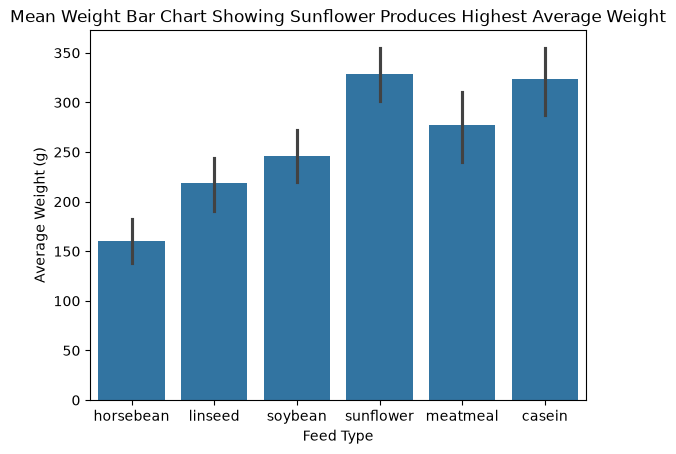

In [8]:
sns.barplot(data=df, x="feed", y="weight")
plt.title("Mean Weight Bar Chart Showing Sunflower Produces Highest Average Weight")
plt.xlabel("Feed Type")
plt.ylabel("Average Weight (g)")

### Histogram of All Weights

Text(0, 0.5, '# of Chickens')

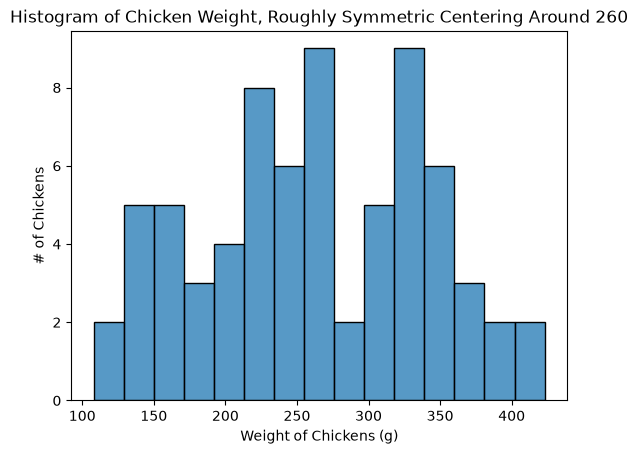

In [9]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Histogram of Chicken Weight, Roughly Symmetric Centering Around 260")
plt.xlabel("Weight of Chickens (g)")
plt.ylabel("# of Chickens")

### Line Chart of Museum Visitors

In [16]:
df2= pd.read_csv("museum_visitors.csv")
df2.head(), df2.info(), df2.shape

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   Date                                  59 non-null     str  
 1   Avila Adobe                           59 non-null     int64
 2   Firehouse Museum                      59 non-null     int64
 3   Chinese American Museum               59 non-null     int64
 4   America Tropical Interpretive Center  59 non-null     int64
dtypes: int64(4), str(1)
memory usage: 2.4 KB


(         Date  Avila Adobe  Firehouse Museum  Chinese American Museum  \
 0  2014-01-01        24778              4486                     1581   
 1  2014-02-01        18976              4172                     1785   
 2  2014-03-01        25231              7082                     3229   
 3  2014-04-01        26989              6756                     2129   
 4  2014-05-01        36883             10858                     3676   
 
    America Tropical Interpretive Center  
 0                                  6602  
 1                                  5029  
 2                                  8129  
 3                                  2824  
 4                                 10694  ,
 None,
 (59, 5))

### Line Chart of Museum Visitors

In [17]:
df2["Date"] = pd.to_datetime(df2["Date"], format="mixed")
df2 = df2.set_index("Date")

Text(0, 0.5, '# of Monthly Visitors')

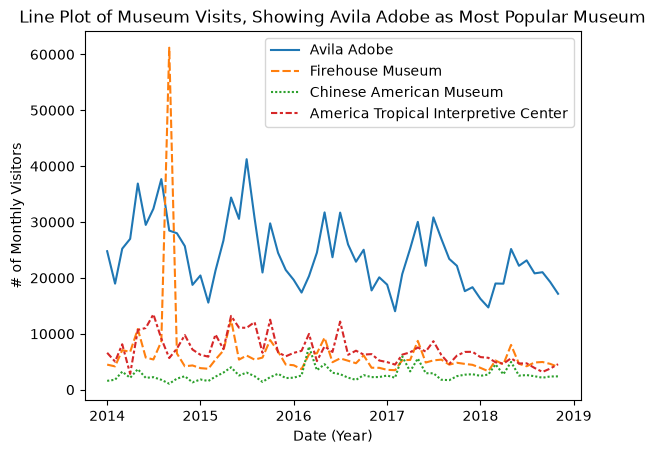

In [23]:
sns.lineplot(data=df2)
plt.title("Line Plot of Museum Visits, Showing Avila Adobe as Most Popular Museum")
plt.xlabel("Date (Year)")
plt.ylabel("# of Monthly Visitors")

#### Line Chart Analysis
Looking at he line chart I notice that Avila Adobe consistenetly has the highest amount of visitors. Visitors at Avila Adobe spike twice a year, however the total amount of visitors is slowly declining year to year. The Firehouse Museum and the America Tropical Interpretive Center seem to have similar visitor numbers, with the America Tropical Interpretive Center averaging slighlty more visitors. I see a giant jump in visitors for the Firehouse Museum in 2014, when comparing it to the rest of the data for the Firehouse Museum I ahve come to the conclusion that it was most likely a typo, where an extra number was added. The Chinese American Museum has the lowest amount of visitors, however it is trending upward slightly, year by year.

### Scatter and Heatmap of Module 4 Sales Data

In [24]:
df3 = pd.read_csv("../module4/sales_clean.csv")
df3.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


In [34]:
df3["revenue"] = df3["price"]*df3["qty"]
df3.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


#### Scatterplot Revenue vs Sales

Text(0, 0.5, 'Revenue($)')

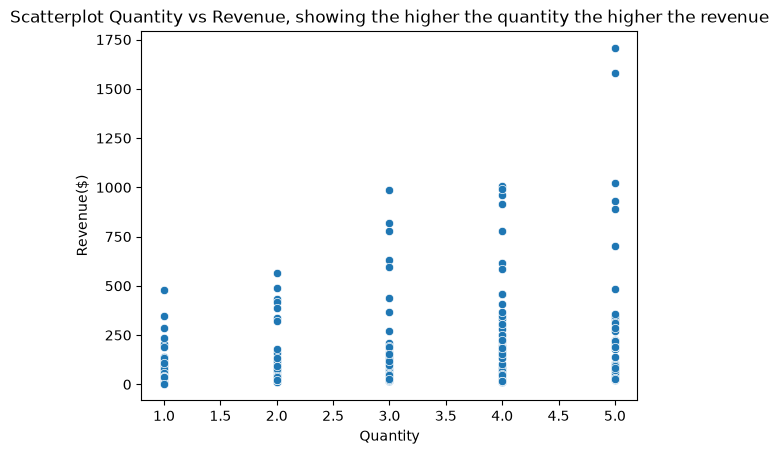

In [32]:
sns.scatterplot(data=df3, x="qty", y="revenue")
plt.title("Scatterplot Quantity vs Revenue, showing the higher the quantity the higher the revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue($)")

<Axes: >

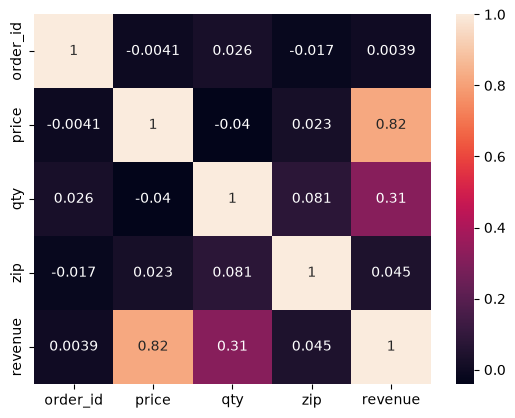

In [35]:
sns.heatmap(df3.corr(numeric_only=True), annot=True)

#### Scatterplot and Heatmap Analysis
While there is a correlation between quantity and revnue, there is a much stronger correlation between price and revenue.

### Null Hypothesis Casein vs Horsebean Fed Chicks
$H_0$ : There is no signifigant weight difference between Casein and Horsebean fed chicks, and any differnce in weight is by chance.

#### T-Test for Casein vs Horsebean Fed Chicks

In [6]:
a= df[df["feed"] == "casein"]["weight"]
b= df[df["feed"] == "horsebean"]["weight"]
ttest_ind(a,b)

TtestResult(statistic=np.float64(7.019741040397541), pvalue=np.float64(8.254541016953186e-07), df=np.float64(20.0))

#### Conclusion
I reject the null hypothesis because casein fed chicks weigh 163.38 grams more than horsebean fed chicks.
($p = 8.25 \times 10^{-7}$)
We should use some caution when viewing this data, as it is from a small sample size from one experiment.

### Honest Chart Audit
For the museum visit line chart, I made two honest design choices:
1. **Zero baseline / no truncation:** I ensured the y-axis started at zero without truncating the lower values, which prevents the smaller museums from looking like they had zero visitors and avoids artificially exaggerating the fluctuations.
2. **Units:** I labeled the vertical axis with the unit of measurement ("# of Monthly Visitors") and the horizontal axis with (Date(year)) , ensuring the viewer does not misinterpret the counts as daily numbers or percentages.
